## Reading PDF files to review our Documents Type

In [1]:
import os
path = r"/home/developer/Dev/Machine-Learning-Projects/Employees_Data_Detection/EmployeesData"
os.listdir(path)

['Contracts',
 'output_images',
 'Passport',
 'Change Status',
 'رسوم عقد عمل.pdf',
 'DUBAI INSURANCE COMPANY.pdf',
 'eVisa',
 'رسوم زيارة ثانية.pdf',
 'New Work Entry Permit - Employee',
 'رسوم تاشيرة عمل.pdf',
 'Residence',
 'رسوم تعديل وضع.pdf']

In [2]:
# Internal folder name
typeFolder = "Contracts"

# Map internal folder names to human-readable names
Folder_Names = {
    "Change Status": "Change_of_Status_Documents",
    "Residence": "Residence_Documents",
    "eVisa Tourism": "Tourism_Visa_Documents",
    "eVisa Employment": "Employment_Visa_Documents",
    "Employment Contract Full Work": "Full_Employment_Contracts",
    "Passport": "Passport_Documents"
}

In [3]:
import os
import fitz  # PyMuPDF

folder_name = Folder_Names.get(typeFolder, typeFolder)

# Full folder path
folder_path = os.path.join(path, typeFolder)

In [4]:
# This is a list comprehension in Python. It creates a list of .pdf files found in the folder folder_path.
files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]
print(files)

['عقد عمل دوام كامل استقدام من الخارج.pdf']


In [5]:
# This is a list comprehension in Python. It creates a list of .pdf files found in the folder folder_path.
files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]

# Open PDF file ( Indices relate to files number in the above list)
if files:
    pdf_path = os.path.join(folder_path, files[0])
    doc = fitz.open(pdf_path)
    text= doc[0].get_text()
    print(f"Reading from: {folder_name}")
    print(text)
else:
    print(f"No PDF files found in: {folder_path}")

Reading from: Contracts
Contract preview
مشاهدة العقد
EMPLOYMENT CONTRACT FULL WORK‌عقد عمل دوام كامل
Work permit (Recruiting a worker from outside the country)
)تصريح العمل (استقدام عامل من خارج الدولة
Work Style
Full Work
 دوام كامل
نمط العمل
Transaction Number
MB291046226AE
 
MB291046226AEرقم املعاملة
It is on Wednesday  Corresponding to  21/05/2025  in UAE
1. Establishment Name
NOOR ALMAMZAR MEDICAL CENTRE L.L.C
Establishment No
1233272
Represented by
ADHAM ALI BAKRI
Passport No
N016323869
Nationality
COMMONWEALTH OF DOMINICA
Title
owner
Emirate
Dubai
Telephone Number
0543726409
E-Mail
hr@nooralmamzar.com
Herein after referred to as the First Party / Employer in this Employment Contract
 
بين كل من 21/05/2025  املوافق االربعاء إنه في يوم
.اسم املنشأة1مركز نور املمزر الطبي ش.ذ.م.م
رقم املنشأة1233272
و يمثلها
ادهم على بكرى
رقم الجوازN016323869ا لجنسية
كمنولث دومينكا
الصفة
مالك
اإلمارة
دبي
رقم الهاتف0543726409البريد االلكترونيhr@nooralmamzar.com
ويشار الى ما ذكر في هذا البند بالطرف اأ

Convert PDF to Image and then use OCR to extract text from the image.


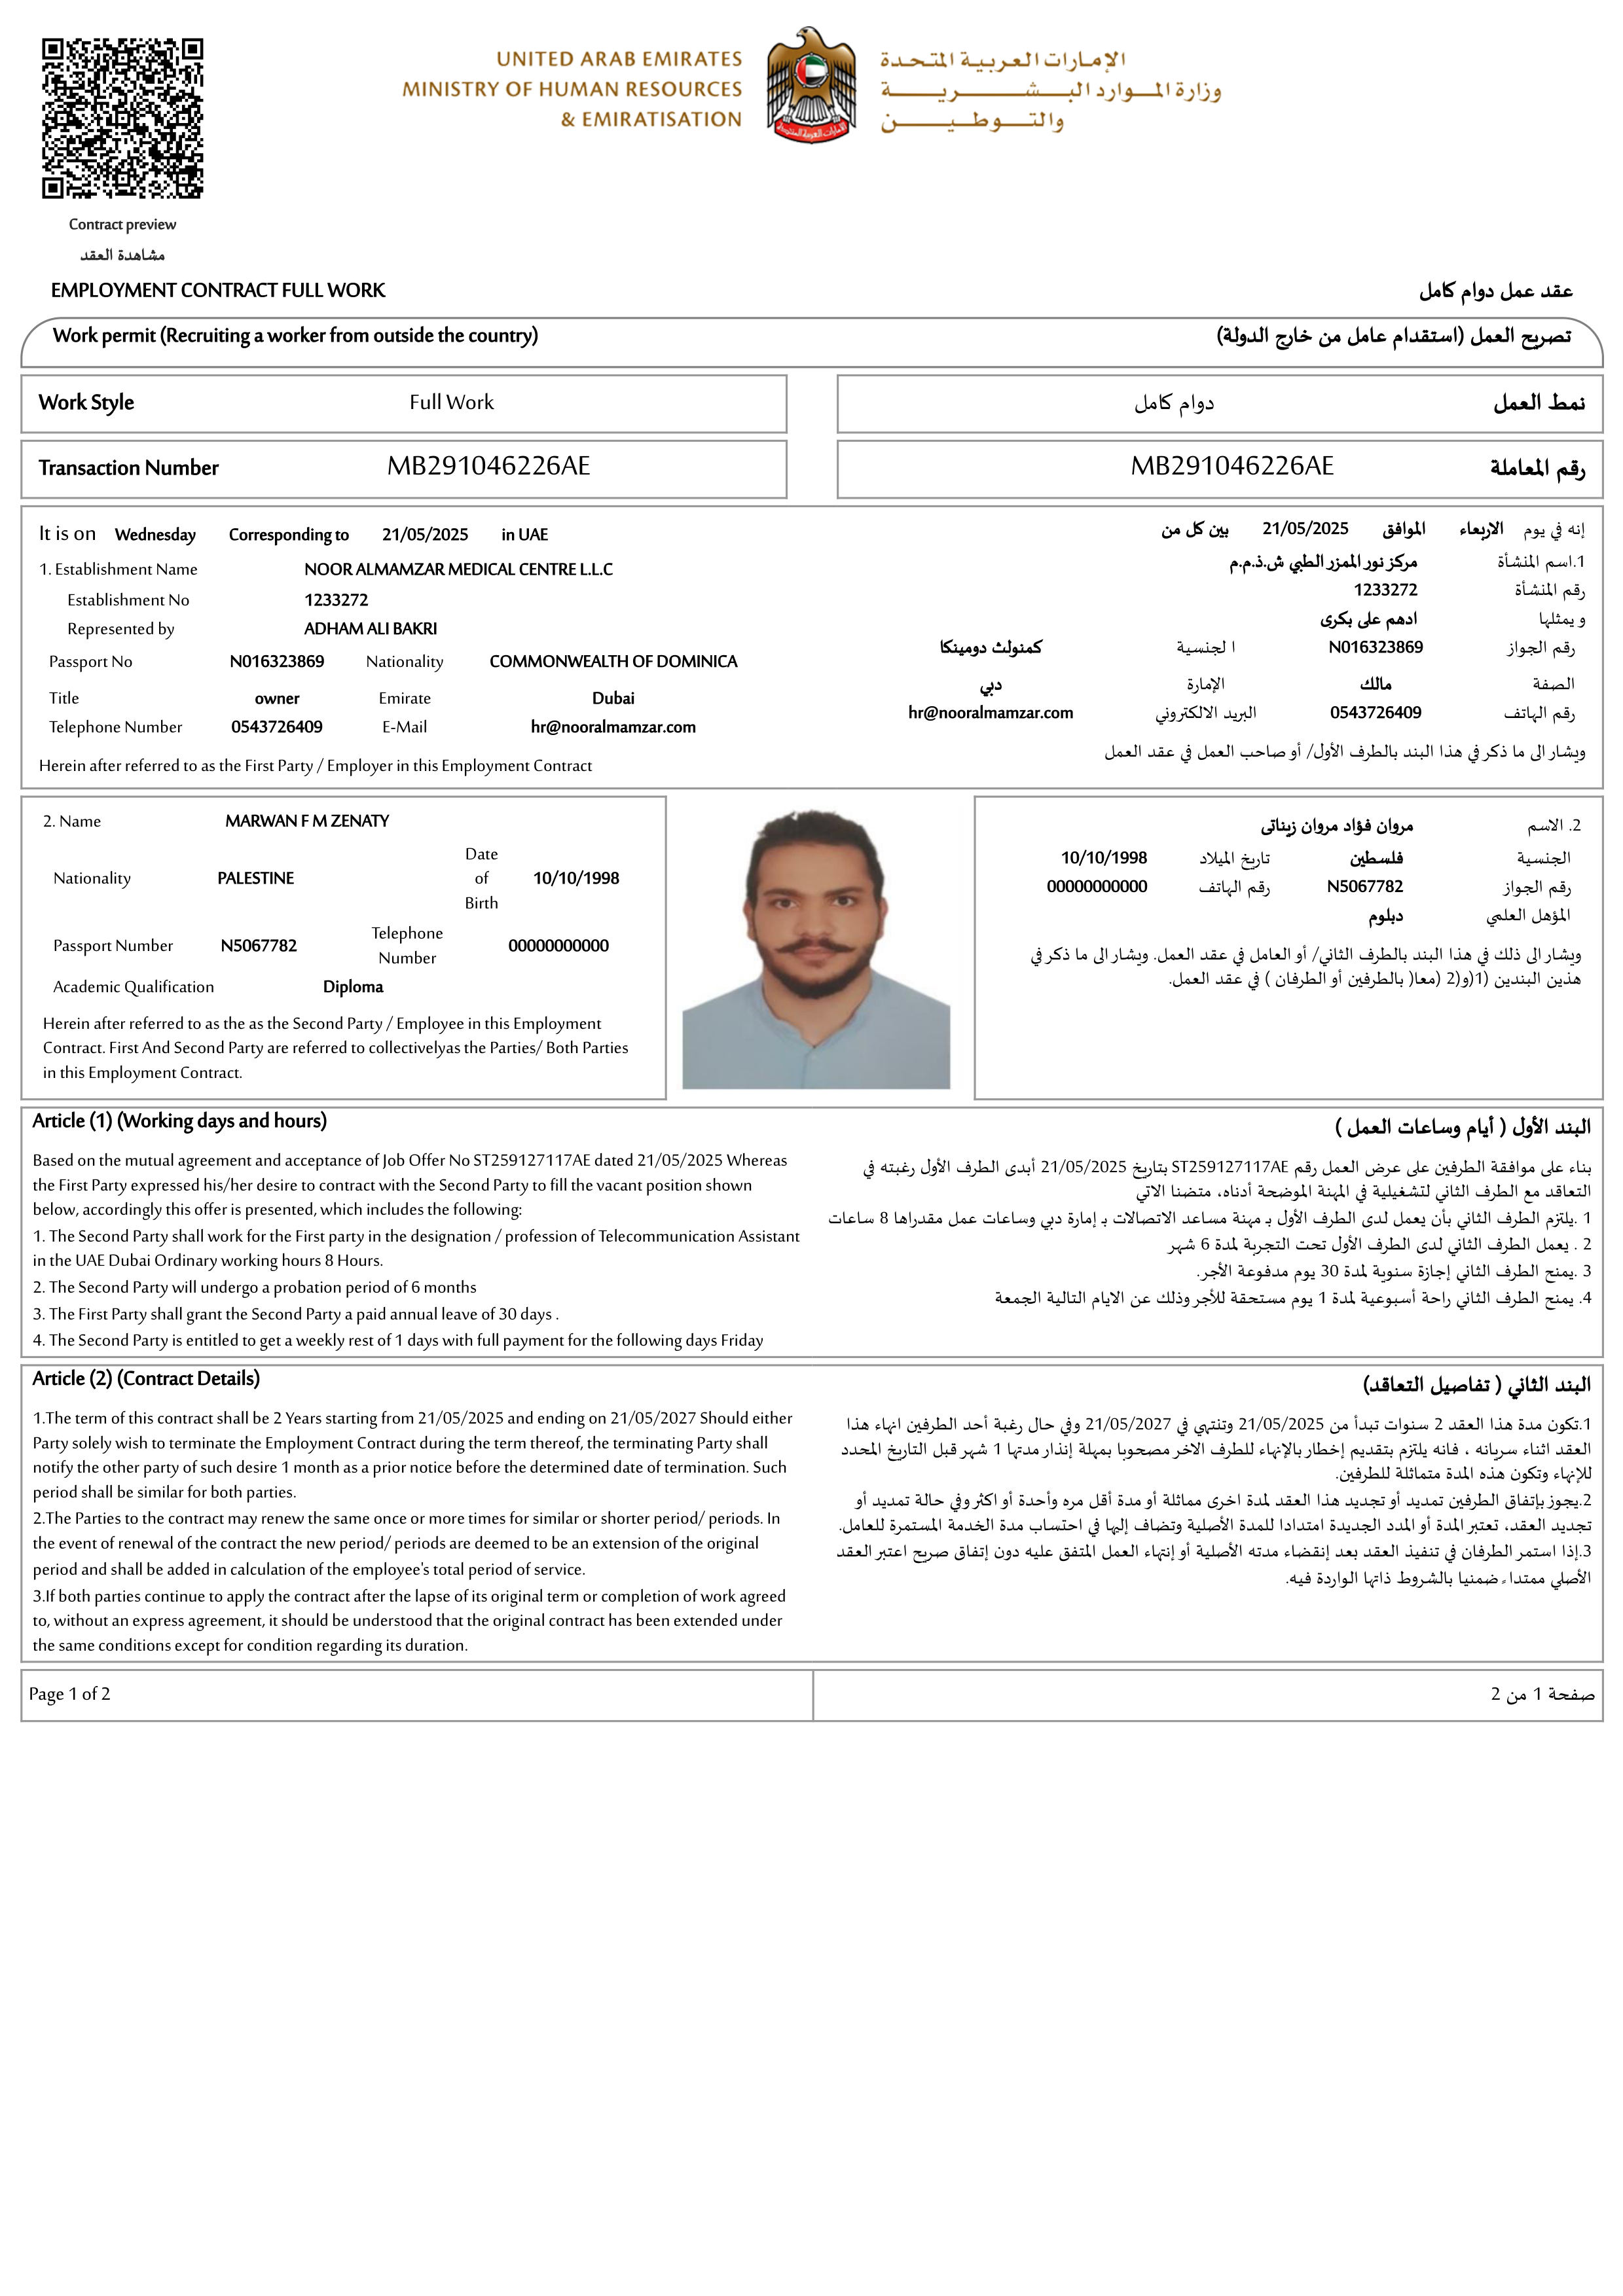

In [6]:
from PIL import Image
import io

import fitz  # PyMuPDF

# Convert each page of the PDF to an image and save/display
pdf_doc = fitz.open(pdf_path)
images = []
for i, page in enumerate(pdf_doc):
    pix = page.get_pixmap(dpi=300)
    img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    images.append(img)
    # Optionally save the image
    img.save(f"page_{i+1}.png")
    # Optionally display the image in notebook
    display(img)
    break

##  Large Language Models (LLMs)

#### 1. QWEN OCR:
- Multilingual Support:
- Trained on large-scale data that includes Chinese, English, and other languages.
- Strong performance on mixed-language content (e.g., Chinese-English text).
- QWEN OCR is a proprietary model focused on text extraction.
- QWEN OCR is specifically designed for extracting text from images of documents, tables, and payslips.
- Qwen2-VL-2B-OCR is a fine-tuned variant of unsloth/Qwen2-VL-2B-Instruct, optimized specifically for Optical Character Recognition (OCR).

In [7]:
"""Please Extract all the information from this image and identify the document type .
if the document is a passport, extract the following fields:
    passport_number, name, date_of_birth, date_of_issue, date_of_expiry, profession, type_of_passport Diplomatic Passport D, Official Passport S, Ordinary Passport P
if the document is a visa, extract the following fields:
    visa_type, issue_date, place_of_issue, valid_until, uid_number, full_name, nationality, place_of_birth, date_of_birth, passport_number, profession
if the document is a change status, extract the following fields:
    uid_number, name, nationality, profession, passport_number, employer_name, residence_stamping_deadline:
if the document is an Employment Contract, extract the following fields:
    work_style, transaction_number, Employee details: (Name, nationality, passport number, date of birth, academic qualification), contract details (contract_start, contract_end)
if the document is a residence, extract the following fields:
    id_number, passport_number, name, profession, issue_date, expiry_date
if the document is a tourism visa, extract the following fields:
    visa_type, issue_date, place_of_issue, valid_until, uid_number, full_name
if healthcare professional registeration certification, extract the following fields:
    professional_name, dha_unique_id

Don't repeat the document type in the response, just extract the fields as specified.
"""

"Please Extract all the information from this image and identify the document type .\nif the document is a passport, extract the following fields:\n    passport_number, name, date_of_birth, date_of_issue, date_of_expiry, profession, type_of_passport Diplomatic Passport D, Official Passport S, Ordinary Passport P\nif the document is a visa, extract the following fields:\n    visa_type, issue_date, place_of_issue, valid_until, uid_number, full_name, nationality, place_of_birth, date_of_birth, passport_number, profession\nif the document is a change status, extract the following fields:\n    uid_number, name, nationality, profession, passport_number, employer_name, residence_stamping_deadline:\nif the document is an Employment Contract, extract the following fields:\n    work_style, transaction_number, Employee details: (Name, nationality, passport number, date of birth, academic qualification), contract details (contract_start, contract_end)\nif the document is a residence, extract the f

In [8]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import requests
import torch
# Define the size dictionary with the required keys
# These values are based on the error message's suggested default if size is None
# You might need to adjust these based on the specific model documentation if available
processor_kwargs = {
    "size": {"shortest_edge": 56 * 56, "longest_edge": 28 * 28 * 1280}
}

# Load model from local path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = r"/home/developer/Dev/Qwen2-VL-2B-OCR"

processor = AutoProcessor.from_pretrained(model_path, **processor_kwargs)

# model = AutoModelForImageTextToText.from_pretrained(model_path, torch_dtype=torch.float16, device_map="auto") # auto device placement, offloading to CPU if needed
model = AutoModelForImageTextToText.from_pretrained(model_path, torch_dtype=torch.float16) # Move model to the specified device (GPU or CPU)

/home/developer/Dev/Machine-Learning-Projects/Employees_Data_Detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [9]:
import torch
print(torch.cuda.is_available())       # Should be True
print(torch.cuda.device_count())       # Should be ≥ 1
print(torch.cuda.get_device_name(0))   # Should print your GPU name


True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [10]:
import os
print(os.environ.get("CUDA_VISIBLE_DEVICES"))


None


In [11]:
import torch
print(torch.__version__)
print(torch.version.cuda)


2.5.1+cu121
12.1


In [12]:
import requests
import torch
import time
from torchvision import io
from typing import Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the right device
model = model.to(device)
conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": (
                    """
Extract all the data from the image
"""
                ),
            },
        ],
    }
]


# Preprocess the inputs
text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
# Excepted output: '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>\n<|im_start|>assistant\n'

inputs = processor(text=[text_prompt], images=[img], padding=True, return_tensors="pt")
# inputs = inputs.to('cuda')
# Move input tensors to the same device
inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}


start = time.time() 
# Inference: Generation of the output
output_ids = model.generate(**inputs, max_new_tokens=2048)
# generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, output_ids)]
generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs["input_ids"], output_ids)]

output_text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
elapsed = time.time() - start
print(f"Inference time: {elapsed:.2f} sec")

Inference time: 13.37 sec


In [13]:
print(output_text[0])

Employment Contract Full Work
Work permit (Recruiting a worker from outside the country)
Transaction Number: MB291046226AE
Rقم العمالقة: MB291046226AE
Employment Contract
Work Style: Full Work
Employer: NOOR ALMAMZAR MEDICAL CENTRE LLC
Represented by: ADHAM ALI BAKRI
Passport No: N016323869
Nationality: COMMONWEALTH OF DOMINICA
Title: Owner
Telephone Number: 0543726409
E-Mail: hr@nooralmamzar.com
Herein after referred to as the First Party / Employer in this Employment Contract
2. Name: MARWAN F M ZENATY
Nationality: PALESTINE
Date of Birth: 10/10/1998
Passport Number: N5067782
Telephone Number: 00000000000
Academic Qualification: Diploma
Herein after referred to as the Second Party / Employee in this Employment Contract
Article (1) (Working days and hours)
Based on the mutual agreement and acceptance of Job Offer No ST259127117AE dated 21/05/2025 Whereas the First Party expressed his/her desire to contract with the Second Party to fill the vacant position shown below, accordingly this

In [14]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

### Estimating VRAM for Qwen2-VL-2B-OCR

In [15]:
def estimate_vram_qwen2_vl(batch_size: int = 10,
                            image_resolution: int = 1024,  # pixels, assume square (or min edge)
                            max_tokens: int = 2048,
                            precision: str = 'fp16') -> float:
    """
    Estimate VRAM required to run Qwen2-VL-2B-OCR based on inputs.

    Returns: VRAM in GB
    """
    # Assume vision encoder adds ~1.2 GB @384px in fp16 per image
    # Model weights (2B params): 2e9 * 2 bytes (fp16) ≈ 4GB
    # Activation memory & decoder usage scales with batch and token count

    precision = precision.lower()
    if precision == 'fp32':
        factor = 4
    elif precision == 'fp16':
        factor = 2
    elif precision == 'int8':
        factor = 1
    else:
        raise ValueError("Unsupported precision")

    model_weight_memory = 2e9 * factor / (1024 ** 3)  # GB

    vision_encoder_memory = batch_size * (1.2 if image_resolution >= 1024 else 0.8)  # GB

    decoder_memory = batch_size * max_tokens * factor * 2 / (1024 ** 2)  # MB → GB
    decoder_memory /= 1024

    overhead_memory = 1.0  # buffers, CUDA, attention cache

    total_vram = model_weight_memory + vision_encoder_memory + decoder_memory + overhead_memory
    return round(total_vram, 2)


In [16]:
vram = estimate_vram_qwen2_vl(batch_size=10, image_resolution=1024, max_tokens=2048, precision='fp16')
print(f"Estimated VRAM needed: {vram} GB")


Estimated VRAM needed: 16.73 GB


**Parameters:**

- batch_size: Number of images/texts processed at once.
- image_resolution: Shortest image edge size in pixels (e.g., 384).
- max_tokens: Number of tokens generated or used during decoding.
- precision: Numeric precision mode (fp16, fp32, or int8).

In [17]:
# Import the os module for operating system functionalities
import os 
# Import load_dotenv function from python-dotenv package
from dotenv import load_dotenv
# Load environment variables from a .env file into the environment
load_dotenv()

True

In [18]:
import os
print(os.getenv("GROQ_API_KEY"))  # Should print your key (or part of it)

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


In [19]:
# Import the ChatGroq class from langchain_groq library for interacting with Groq's API
import os
import fitz  # PyMuPDF
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Optional
from langchain_core.runnables import Runnable

# Initialize a ChatGroq instance with the following parameters:
# - model: Using the "deepseek-r1-distill-llama-70b" model
# - temperature: Set to 0.7 (higher values make output more random/creative)
# - max_tokens: Limit the response to 1024 tokens maximum
llm = ChatGroq(
    model="deepseek-r1-distill-llama-70b",
    temperature=0.0,
    max_tokens=1024,
)

In [20]:
from pydantic import BaseModel, Field, ValidationError
from typing import Optional, Union, List
from enum import Enum


class PersonalInfo(str, Enum):
    CONTRACT = "EMPLOYMENT CONTRACT FULL WORK"
    TOURISM_VISA = "eVisa - Tourism"
    EMPLOYMENT_VISA = "eVisa - Employment"
    RESIDENCE = "Residence"
    CHANGE_STATUS = "Change Status"
    HEALTHCARE = "Healthcare Professional Registration Certificate"
    PASSPORT = "Passport"


class ContractData(BaseModel):
    work_style: Optional[str] = Field(
        None, description="Type of work (e.g., Full time, Part time, Temporary)"
    )
    transaction_number: Optional[List[str]] = Field(
        None, description="Transaction number used by MOHRE"
    )
    name: Optional[str] = Field(None, description="Full legal name of the employee")
    nationality: Optional[str] = Field(None, description="Nationality of the employee")
    passport_number: Optional[str] = Field(None, description="Passport number")
    date_of_birth: Optional[List[str]] = Field(
        None, description="Date of birth (YYYY-MM-DD or as found)"
    )
    academic_qualification: Optional[str] = Field(
        None, description="Academic qualification"
    )
    contract_start: Optional[str] = Field(
        None, description="Start date of the contract"
    )
    contract_end: Optional[str] = Field(None, description="End date of the contract")


class VisaData(BaseModel):
    issue_date: Optional[str] = Field(
        None, description="Visa issue date (YYYY-MM-DD or as found) or similar format"
    )
    place_of_issue: Optional[str] = Field(
        None,
        description="Place of issue where the visa was issued and stamped by the Country government",
    )
    valid_until: Optional[str] = Field(None, description="Visa expiration date")
    uid_number: Optional[str] = Field(None, description="UID number (9 to 15 digits)")
    full_name: Optional[str] = Field(None, description="Full name of the visa holder")
    nationality: Optional[str] = Field(None, description="Nationality")
    place_of_birth: Optional[str] = Field(None, description="Place of birth")
    date_of_birth: Optional[str] = Field(None, description="Date of birth")
    passport_number: Optional[str] = Field(None, description="Passport number")
    profession: Optional[str] = Field(None, description="Profession listed")


class ResidenceData(BaseModel):
    id_number: Optional[str] = Field(
        None, description="ID number, may contain Arabic characters"
    )
    passport_number: Optional[str] = Field(None, description="Passport number")
    name: Optional[str] = Field(None, description="Full name")
    profession: Optional[str] = Field(None, description="Profession")
    issue_date: Optional[str] = Field(None, description="Issue date")
    expiry_date: Optional[str] = Field(None, description="Expiration date")


class ChangeStatusData(BaseModel):
    uid_number: Optional[str] = Field(None, description="UID number")
    name: Optional[str] = Field(None, description="Full name")
    nationality: Optional[str] = Field(None, description="Nationality")
    profession: Optional[str] = Field(None, description="Profession")
    passport_number: Optional[str] = Field(None, description="Passport number")
    employer_name: Optional[str] = Field(None, description="Employer name")
    residence_stamping_deadline: Optional[str] = Field(
        None, description="Deadline for residence stamping"
    )


class HealthcareRegistrationData(BaseModel):
    professional_name: Optional[str] = Field(
        None, description="Name of healthcare professional"
    )
    dha_unique_id: Optional[str] = Field(None, description="DHA Unique Identifier")


class PassportData(BaseModel):
    passport_number: Optional[str] = Field(None, description="Passport number")
    name: Optional[str] = Field(None, description="Full name on passport")
    date_of_birth: Optional[str] = Field(None, description="Date of birth")
    date_of_issue: Optional[str] = Field(None, description="Date of issue")
    date_of_expiry: Optional[str] = Field(None, description="Date of expiry")
    profession: Optional[str] = Field(None, description="Profession listed")


# Unified Document Schema


class DocumentSchema(BaseModel):
    document_type: PersonalInfo = Field(..., description="The document type")
    contractDetails: Optional[Union[ContractData, List[ContractData]]] = Field(
        None, description="Extracted contract details"
    )
    visaDetails: Optional[Union[VisaData, List[VisaData]]] = Field(
        None, description="Extracted visa details"
    )
    residenceDetails: Optional[Union[ResidenceData, List[ResidenceData]]] = Field(
        None, description="Extracted residence details"
    )
    changeStatusDetails: Optional[Union[ChangeStatusData, List[ChangeStatusData]]] = (
        Field(None, description="Extracted change status details")
    )
    healthcareDetails: Optional[
        Union[HealthcareRegistrationData, List[HealthcareRegistrationData]]
    ] = Field(None, description="Extracted healthcare details")
    passportDetails: Optional[Union[PassportData, List[PassportData]]] = Field(
        None, description="Extracted passport details"
    )

In [21]:
from pydantic import BaseModel, Field, ValidationError
from typing import Optional, Union, List
from enum import Enum


class PersonalInfo(str, Enum):
    CONTRACT = "EMPLOYMENT CONTRACT FULL WORK"
    TOURISM_VISA = "eVisa - Tourism"
    EMPLOYMENT_VISA = "eVisa - Employment"
    RESIDENCE = "Residence"
    CHANGE_STATUS = "Change Status"
    HEALTHCARE = "Healthcare Professional Registration Certificate"
    PASSPORT = "Passport"
    
    
class ContractData(BaseModel):
    work_style: Optional[str]
    transaction_number: Optional[str]  # Changed from List[str]
    name: Optional[str]
    nationality: Optional[str]
    passport_number: Optional[str]
    date_of_birth: Optional[str]  # Changed from List[str]
    academic_qualification: Optional[str]
    contract_start: Optional[str]
    contract_end: Optional[str]
    
    
class VisaData(BaseModel):
    issue_date: Optional[str]
    place_of_issue: Optional[str]
    valid_until: Optional[str]
    uid_number: Optional[str]
    full_name: Optional[str]
    nationality: Optional[str]
    place_of_birth: Optional[str]
    date_of_birth: Optional[str]
    passport_number: Optional[str]
    profession: Optional[str]

class ResidenceData(BaseModel):
    id_number: Optional[str]
    passport_number: Optional[str]
    name: Optional[str]
    profession: Optional[str]
    issue_date: Optional[str]
    expiry_date: Optional[str]

class ChangeStatusData(BaseModel):
    uid_number: Optional[str]
    name: Optional[str]
    nationality: Optional[str]
    profession: Optional[str]
    passport_number: Optional[str]
    employer_name: Optional[str]
    residence_stamping_deadline: Optional[str]


class HealthcareRegistrationData(BaseModel):
    professional_name: Optional[str]
    dha_unique_id: Optional[str]


class PassportData(BaseModel):
    passport_number: Optional[str]
    name: Optional[str]
    date_of_birth: Optional[str]
    date_of_issue: Optional[str]
    date_of_expiry: Optional[str]
    profession: Optional[str]

class DocumentSchema(BaseModel):
    document_type: PersonalInfo
    contractDetails: Optional[List[ContractData]] = None
    visaDetails: Optional[List[VisaData]] = None
    residenceDetails: Optional[List[ResidenceData]] = None
    changeStatusDetails: Optional[List[ChangeStatusData]] = None
    healthcareDetails: Optional[List[HealthcareRegistrationData]] = None
    passportDetails: Optional[List[PassportData]] = None




In [22]:
structured_llm = llm.with_structured_output(DocumentSchema)

schema_template = """
Your task is to extract all structured data from the provided document.
The document type could be one of the following:
- EMPLOYMENT CONTRACT FULL WORK
- eVisa - Tourism
- eVisa - Employment
- Residence
- Change Status
- Passport
- Healthcare Professional Registration Certificate

Here is the document text:

{extractedData}

Extract the data according to the corresponding fields and return the structured JSON schema.
Start!
"""


In [23]:
schema_prompt = ChatPromptTemplate.from_template(schema_template)
schema_chain = schema_prompt | structured_llm

In [24]:
q = schema_chain.invoke({"extractedData": output_text})
q

DocumentSchema(document_type=<PersonalInfo.CONTRACT: 'EMPLOYMENT CONTRACT FULL WORK'>, contractDetails=[ContractData(work_style='Full Work', transaction_number='MB291046226AE', name='MARWAN F M ZENATY', nationality='PALESTINE', passport_number='N5067782', date_of_birth='10/10/1998', academic_qualification='Diploma', contract_start='21/05/2025', contract_end='21/05/2027')], visaDetails=None, residenceDetails=None, changeStatusDetails=None, healthcareDetails=None, passportDetails=None)

In [25]:
q.model_dump_json()

'{"document_type":"EMPLOYMENT CONTRACT FULL WORK","contractDetails":[{"work_style":"Full Work","transaction_number":"MB291046226AE","name":"MARWAN F M ZENATY","nationality":"PALESTINE","passport_number":"N5067782","date_of_birth":"10/10/1998","academic_qualification":"Diploma","contract_start":"21/05/2025","contract_end":"21/05/2027"}],"visaDetails":null,"residenceDetails":null,"changeStatusDetails":null,"healthcareDetails":null,"passportDetails":null}'

In [26]:
q.model_dump_json()

import json
parsed = json.loads(q.model_dump_json())
pretty_output = json.dumps(parsed, indent=4)
print(pretty_output)

{
    "document_type": "EMPLOYMENT CONTRACT FULL WORK",
    "contractDetails": [
        {
            "work_style": "Full Work",
            "transaction_number": "MB291046226AE",
            "name": "MARWAN F M ZENATY",
            "nationality": "PALESTINE",
            "passport_number": "N5067782",
            "date_of_birth": "10/10/1998",
            "academic_qualification": "Diploma",
            "contract_start": "21/05/2025",
            "contract_end": "21/05/2027"
        }
    ],
    "visaDetails": null,
    "residenceDetails": null,
    "changeStatusDetails": null,
    "healthcareDetails": null,
    "passportDetails": null
}


In [27]:
def extract_clean_json(parsed: dict) -> str:
    doc_type = parsed.get("document_type")

    # Keep the root key
    result = {"document_type": doc_type}

    # Map document types to the corresponding fields
    field_map = {
        "EMPLOYMENT CONTRACT FULL WORK": "contractDetails",
        "eVisa - Tourism": "visaDetails",
        "eVisa - Employment": "visaDetails",
        "Residence": "residenceDetails",
        "Change Status": "changeStatusDetails",
        "Passport": "passportDetails",
        "Healthcare Professional Registration Certificate": "healthcareDetails",
    }

    target_field = field_map.get(doc_type)
    if target_field and parsed.get(target_field):
        result[target_field] = parsed[target_field]

    return json.dumps(result, indent=4)

In [28]:
parsed = json.loads(q.model_dump_json())  # or directly q.model_dump()
clean_json = extract_clean_json(parsed)
print(clean_json)

{
    "document_type": "EMPLOYMENT CONTRACT FULL WORK",
    "contractDetails": [
        {
            "work_style": "Full Work",
            "transaction_number": "MB291046226AE",
            "name": "MARWAN F M ZENATY",
            "nationality": "PALESTINE",
            "passport_number": "N5067782",
            "date_of_birth": "10/10/1998",
            "academic_qualification": "Diploma",
            "contract_start": "21/05/2025",
            "contract_end": "21/05/2027"
        }
    ]
}


In [29]:
import json
import pandas as pd
from IPython.display import display, HTML

# Step 1: Dump JSON from model output
parsed = json.loads(q.model_dump_json())

# Step 2: Pretty-print JSON (optional debug output)
pretty_output = json.dumps(parsed, indent=4)
print(pretty_output)

# Step 3: Visualize the data according to document type
def visualize_by_doc_type(data: dict):
    doc_type = data.get("document_type", "Unknown")

    display(HTML(f"<h2>📄 Document Type: <i>{doc_type}</i></h2>"))

    def show_table(records, section_name):
        if records:
            df = pd.DataFrame(records)
            for col in df.columns:
                df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) and x else x)
            display(HTML(f"<h3>🔍 {section_name}</h3>"))
            display(df.style.set_table_styles(
                [{'selector': 'th', 'props': [('background-color', "#0f0916"), ('text-align', 'left')]}]
            ).set_properties(**{'text-align': 'left', 'border': '1px solid #ccc'}))
        else:
            display(HTML(f"<p style='color: gray;'>ℹ️ No data found for <b>{section_name}</b>.</p>"))

    # Dispatch visualization based on document_type
    if doc_type == "EMPLOYMENT CONTRACT FULL WORK":
        show_table(data.get("contractDetails"), "Employment Contract Details")

    elif doc_type in ["eVisa - Tourism", "eVisa - Employment"]:
        show_table(data.get("visaDetails"), "Visa Details")

    elif doc_type == "Residence":
        show_table(data.get("residenceDetails"), "Residence Details")

    elif doc_type == "Change Status":
        show_table(data.get("changeStatusDetails"), "Change Status Details")

    elif doc_type == "Passport":
        show_table(data.get("passportDetails"), "Passport Details")

    elif doc_type == "Healthcare Professional Registration Certificate":
        show_table(data.get("healthcareDetails"), "Healthcare Registration Details")

    else:
        display(HTML("<p style='color: red;'>❌ Unsupported or unknown document type.</p>"))

# Step 4: Call the function
visualize_by_doc_type(parsed)


{
    "document_type": "EMPLOYMENT CONTRACT FULL WORK",
    "contractDetails": [
        {
            "work_style": "Full Work",
            "transaction_number": "MB291046226AE",
            "name": "MARWAN F M ZENATY",
            "nationality": "PALESTINE",
            "passport_number": "N5067782",
            "date_of_birth": "10/10/1998",
            "academic_qualification": "Diploma",
            "contract_start": "21/05/2025",
            "contract_end": "21/05/2027"
        }
    ],
    "visaDetails": null,
    "residenceDetails": null,
    "changeStatusDetails": null,
    "healthcareDetails": null,
    "passportDetails": null
}


,work_style,transaction_number,name,nationality,passport_number,date_of_birth,academic_qualification,contract_start,contract_end
0,Full Work,MB291046226AE,MARWAN F M ZENATY,PALESTINE,N5067782,10/10/1998,Diploma,21/05/2025,21/05/2027


In [30]:
import pandas as pd

# Convert to dictionary
data_dict = q.model_dump()

# Convert to DataFrame and transpose for vertical layout
pd.DataFrame(data_dict.items(), columns=["Field", "Value"])


,Field,Value
0,document_type,PersonalInfo.CONTRACT
1,contractDetails,"[{'work_style': 'Full Work', 'transaction_numb..."
2,visaDetails,None
3,residenceDetails,None
4,changeStatusDetails,None
5,healthcareDetails,None
6,passportDetails,None


In [31]:
def extract_clean_json(parsed: dict) -> str:
    doc_type = parsed.get("document_type")

    # Keep the root key
    result = {"document_type": doc_type}

    # Map document types to the corresponding fields
    field_map = {
        "EMPLOYMENT CONTRACT FULL WORK": "contractDetails",
        "eVisa - Tourism": "visaDetails",
        "eVisa - Employment": "visaDetails",
        "Residence": "residenceDetails",
        "Change Status": "changeStatusDetails",
        "Passport": "passportDetails",
        "Healthcare Professional Registration Certificate": "healthcareDetails",
    }

    target_field = field_map.get(doc_type)
    if target_field and parsed.get(target_field):
        result[target_field] = parsed[target_field]

    return json.dumps(result, indent=4)

In [32]:
parsed = json.loads(q.model_dump_json())  # or directly q.model_dump()
clean_json = extract_clean_json(parsed)
print(clean_json)

{
    "document_type": "EMPLOYMENT CONTRACT FULL WORK",
    "contractDetails": [
        {
            "work_style": "Full Work",
            "transaction_number": "MB291046226AE",
            "name": "MARWAN F M ZENATY",
            "nationality": "PALESTINE",
            "passport_number": "N5067782",
            "date_of_birth": "10/10/1998",
            "academic_qualification": "Diploma",
            "contract_start": "21/05/2025",
            "contract_end": "21/05/2027"
        }
    ]
}
